In [1]:
import pandas as pd
enzyme_df= pd.read_csv('../../data/enzyme_dataset_seq.csv')
enzyme_df= enzyme_df[~enzyme_df['Sequence'].isna()]
enzyme_go_terms = [gt.split("'")[1] for gt in enzyme_df['GOTerm']]
import json
train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
term_ind_map = {t:i for i, t in enumerate(go_terms)}
enzyme_df['GOTerm'] = enzyme_go_terms
enzyme_df= enzyme_df[enzyme_df['GOTerm'].isin(term_ind_map)]
enzyme_term_index = [term_ind_map[t] for t in enzyme_df['GOTerm']]
enzyme_df['GOTermIndex'] = enzyme_term_index
annotated_indices = [list(filter(lambda x: x < min(1024, len(seq)), map(int, x[1:-1].split(',')))) for x, seq in zip(enzyme_df['AnnotatedIndices'], enzyme_df['Sequence'])]
enzyme_df['AnnotatedIndices'] = annotated_indices

import transformers
tokenizer = transformers.AutoTokenizer.from_pretrained('facebook/esm2_t6_8M_UR50D')
def enzyme_iterator():
     for i, pid, annot_ind, enzyme_cls, goterm, seq, go_ind in enzyme_df.itertuples():
          # print(pid, annot_ind, enzyme_cls, goterm, seq, go_ind)
          inputs = tokenizer.batch_encode_plus([seq], add_special_tokens=True, padding='max_length',
                                             truncation=True, return_attention_mask=True, max_length=1024)
          yield {'prot_id': pid, 'annot_ind': annot_ind, 'go_ind': go_ind, 'seq': seq, 'seq_ind': inputs['input_ids'], 'mask': inputs['attention_mask']}

/home/andrew/anaconda3/envs/gointerp/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import torch
import torch.nn as nn
import pickle
from go_ml.models.bert_finetune import BERTFinetune
device = torch.device('cuda:0')

checkpoint_dir = "/home/andrew/GO_interp/checkpoints"
with open(f"{checkpoint_dir}/esm_finetune_hparams.pkl", "rb") as f:
    hparams = pickle.load(f)
model = BERTFinetune.load_from_checkpoint(f"{checkpoint_dir}/esm_finetune.ckpt", model_args=hparams, 
                                          map_location=device)
class SingleGOModel(nn.Module):
    def __init__(self, model, go_idx):
        super().__init__()
        self.model = model
        self.go_idx = go_idx

    def forward(self, seq, mask, go_idx):
        return torch.sigmoid(self.model(seq, mask)[:, go_idx])
goind_model = SingleGOModel(model, 0)
goind_model.eval()
print("Model ready")

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


AttributeError: 'Namespace' object has no attribute 'cls_bottleneck'

In [4]:
def get_preds(model, iter):
    with torch.no_grad():
        pred_l = []
        for i, r in enumerate(iter):
            seq_ind, mask =  torch.tensor(r['seq_ind']).to(device), torch.BoolTensor(r['mask']).to(device)
            pred = model(seq_ind, mask, r['go_ind'])
            pred_l.append(pred.cpu())
            if(i % 100 == 0): 
                print(i)
        return pred_l
pred_l = get_preds(goind_model, enzyme_iterator())
preds = torch.stack(pred_l)

0
100
200
300
400
500
600
700


In [ ]:
from captum.attr import LayerActivation
# token_reference = TokenReferenceBase(reference_token_idx=0)
lact = LayerActivation(goind_model, goind_model.model.model.embeddings.word_embeddings)

def get_attributions_layer_act(lig, iter):
    attributions_lact_l = []
    for i, r in enumerate(iter):
        seq_ind, mask =  torch.tensor(r['seq_ind']).to(device), torch.BoolTensor(r['mask']).to(device)
        # reference_indices = token_reference.generate_reference(seq_ind.shape[1], device=device).unsqueeze(0)
        attributions_lact = lact.attribute(seq_ind, additional_forward_args=(mask.to(device), r['go_ind']))
        attributions_lact_l.append(attributions_lact.cpu())
        if(i % 50 == 0): 
            print(i)
    return attributions_lact_l
attributions_lact_l = get_attributions_layer_act(lact, enzyme_iterator())

In [129]:
from captum.attr import FeatureAblation
# token_reference = TokenReferenceBase(reference_token_idx=0)
lfa = FeatureAblation(goind_model)

def get_attributions_feature_abl(lfa, iter):
    attributions_lfa_l = []
    for i, r in enumerate(iter):
        seq_ind, mask =  torch.tensor(r['seq_ind']).to(device), torch.BoolTensor(r['mask']).to(device)
        attributions_lfa = lfa.attribute(seq_ind, additional_forward_args=(mask.to(device), r['go_ind']), perturbations_per_eval=16)
        attributions_lfa_l.append(attributions_lfa.cpu())
        if(i % 10 == 0):
            print(i)
    return attributions_lfa_l
attributions_lfa_l = get_attributions_feature_abl(lfa, enzyme_iterator())

0
10
20
30
40
50
60
70
80
90
100
110
120
130
140
150
160
170
180
190
200
210
220
230
240
250
260
270
280
290
300
310
320
330
340
350
360
370
380
390
400
410
420
430
440
450
460
470
480
490
500
510
520
530
540
550
560
570
580
590
600
610
620
630
640
650
660
670
680
690
700
710
720
730
740
750
760
770
780


In [ ]:
from captum.attr import LayerIntegratedGradients, TokenReferenceBase, visualization
token_reference = TokenReferenceBase(reference_token_idx=0)
lig = LayerIntegratedGradients(goind_model, goind_model.model.model.embeddings.word_embeddings)

def get_attributions(lig, iter):
    attributions_ig_l, delta_l = [], []
    for i, r in enumerate(iter):
        seq_ind, mask =  torch.tensor(r['seq_ind']).to(device), torch.BoolTensor(r['mask']).to(device)
        reference_indices = token_reference.generate_reference(seq_ind.shape[1], device=device).unsqueeze(0)
        attributions_ig, delta = lig.attribute(seq_ind, reference_indices, \
                                           n_steps=8, return_convergence_delta=True, 
                                           additional_forward_args=(mask.to(device), r['go_ind']))
        attributions_ig_l.append(attributions_ig.cpu())
        delta_l.append(delta)
        if(i % 10 == 0): 
            print(i)
    return attributions_ig_l, delta_l
attributions_l, delta_l = get_attributions(lig, enzyme_iterator())

In [134]:
import pickle
attributions_ig = torch.stack(attributions_l).squeeze().cpu()
attributions_lact = torch.stack(attributions_lact_l).squeeze().cpu()
attributions_lfa = torch.stack(attributions_lfa_l).squeeze().cpu()
attr_dict = {'attributions_ig': attributions_ig, 'attributions_lact': attributions_lact, 'attributions_lfa': attributions_lfa}
with open('../../data/enzyme_attributions.pkl', 'wb') as f:
    pickle.dump(attr_dict, f)

In [123]:
def mean_reciprocal_rank(token_attribution, conserved_tokens):
    token_attribution =  token_attribution - 1e5*(token_attribution == 0) #Ignore padding
    attribution_argsort = torch.argsort(token_attribution, dim=1, descending=True)
    attribution_ranks = torch.argsort(attribution_argsort, dim=1, descending=False)
    ttr = 0
    tct = 0
    for i, token_ind in enumerate(conserved_tokens):
        token_ranks = attribution_ranks[i, token_ind]
        ttr += torch.divide(1, token_ranks+1).sum()
        tct += token_ranks.shape[0]
    return ttr / tct

def mean_percent_rank(token_attribution, seq_len, conserved_tokens):
    token_mask = torch.tile(torch.arange(0, 1024).reshape(1, -1), (sum_attributions.shape[0], 1))
    token_mask[:, 0] += 1024
    token_mask = token_mask < seq_len.reshape(-1, 1)
    token_attribution =  token_attribution.clone() - 1e5*(~token_mask)
    # for i, token_ind in enumerate(conserved_tokens):
    #     token_attribution[i, token_ind] += 10
    attribution_argsort = torch.argsort(token_attribution, dim=1, descending=True)
    attribution_ranks = torch.argsort(attribution_argsort, dim=1, descending=False)
    # print(conserved_tokens[0])
    # print('top k top k', torch.topk(token_attribution[0], 10))
    # print('attribution top k', attribution_argsort[0, :10])

    # print(token_attribution[0, conserved_tokens[0]])
    # print(token_attribution[0, attribution_argsort[0]])
    # print(attribution_ranks[0, conserved_tokens[0]])

    # print('conserved', conserved_tokens[0])
    # print('conserved', attribution_ranks[0, conserved_tokens[0]])
    attribution_percent_rank = attribution_ranks / seq_len.reshape(-1, 1)
    ttr = 0
    tct = 0
    for i, token_ind in enumerate(conserved_tokens):
        # print(token_ind)
        token_ranks = attribution_percent_rank[i, token_ind]
        # print(token_ranks)
        ttr += token_ranks.sum()
        tct += token_ranks.shape[0]
    return ttr / tct

attributions = torch.stack(attributions_l).squeeze().cpu()
sum_attributions = attributions.sum(dim=2)
magn_attributions = attributions.norm(dim=2)

print("Integrated Gradients (Sum)")
mrr = mean_reciprocal_rank(sum_attributions, enzyme_df['AnnotatedIndices'])
mpr = mean_percent_rank(sum_attributions, torch.tensor([len(s) for s in enzyme_df['Sequence']]), list(enzyme_df['AnnotatedIndices']))
print(f'Mean-Reciprocal Rank {mrr}, Mean-Percentage Rank {mpr}')

mrr = mean_reciprocal_rank(magn_attributions, enzyme_df['AnnotatedIndices'])
mpr = mean_percent_rank(magn_attributions, torch.tensor([len(s) for s in enzyme_df['Sequence']]), list(enzyme_df['AnnotatedIndices']))
print(f'Mean-Reciprocal Rank {mrr}, Mean-Percentage Rank {mpr}')

Integrated Gradients (Sum)
Mean-Reciprocal Rank 0.03425345942378044, Mean-Percentage Rank 0.4862583875656128
Mean-Reciprocal Rank 0.04163355380296707, Mean-Percentage Rank 0.3963983952999115


In [124]:
attributions = torch.stack(attributions_lact_l).squeeze().cpu()
sum_attributions = attributions.sum(dim=2)
magn_attributions = attributions.norm(dim=2)

mrr = mean_reciprocal_rank(sum_attributions, enzyme_df['AnnotatedIndices'])
mpr = mean_percent_rank(sum_attributions, torch.tensor([len(s) for s in enzyme_df['Sequence']]), list(enzyme_df['AnnotatedIndices']))
print(f'Mean-Reciprocal Rank {mrr}, Mean-Percentage Rank {mpr}')

mrr = mean_reciprocal_rank(magn_attributions, enzyme_df['AnnotatedIndices'])
mpr = mean_percent_rank(magn_attributions, torch.tensor([len(s) for s in enzyme_df['Sequence']]), list(enzyme_df['AnnotatedIndices']))
print(f'Mean-Reciprocal Rank {mrr}, Mean-Percentage Rank {mpr}')

Mean-Reciprocal Rank 0.010042100213468075, Mean-Percentage Rank 0.5662215352058411
Mean-Reciprocal Rank 0.0015473675448447466, Mean-Percentage Rank 0.3846314251422882


In [133]:
attributions = torch.stack(attributions_lfa_l).squeeze()
mrr = mean_reciprocal_rank(attributions, enzyme_df['AnnotatedIndices'])
mpr = mean_percent_rank(attributions, torch.tensor([len(s) for s in enzyme_df['Sequence']]), list(enzyme_df['AnnotatedIndices']))
print(f'Mean-Reciprocal Rank {mrr}, Mean-Percentage Rank {mpr}')

Mean-Reciprocal Rank 0.03193849325180054, Mean-Percentage Rank 0.49276044964790344


In [127]:
attributions = torch.stack(attributions_lfa_l).squeeze().cpu()
print(attributions.shape)

torch.Size([785, 1024, 320])


In [126]:
attributions = torch.stack(attributions_lfa_l).squeeze().cpu()
sum_attributions = attributions.sum(dim=2)
magn_attributions = attributions.norm(dim=2)

mrr = mean_reciprocal_rank(sum_attributions, enzyme_df['AnnotatedIndices'])
mpr = mean_percent_rank(sum_attributions, torch.tensor([len(s) for s in enzyme_df['Sequence']]), list(enzyme_df['AnnotatedIndices']))
print(f'Mean-Reciprocal Rank {mrr}, Mean-Percentage Rank {mpr}')

mrr = mean_reciprocal_rank(magn_attributions, enzyme_df['AnnotatedIndices'])
mpr = mean_percent_rank(magn_attributions, torch.tensor([len(s) for s in enzyme_df['Sequence']]), list(enzyme_df['AnnotatedIndices']))
print(f'Mean-Reciprocal Rank {mrr}, Mean-Percentage Rank {mpr}')

Mean-Reciprocal Rank 0.010042100213468075, Mean-Percentage Rank 0.5662215352058411
Mean-Reciprocal Rank 0.0015473675448447466, Mean-Percentage Rank 0.3846314251422882


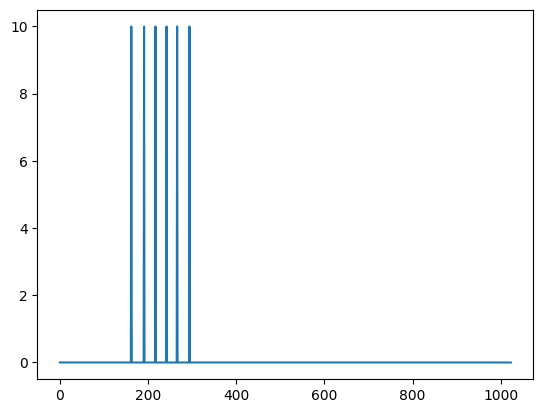

In [61]:
import matplotlib.pyplot as plt
plt.plot(sum_attributions[0])
plt.show()

NameError: name 'seq_len' is not defined

In [37]:
1/0.0029

344.82758620689657

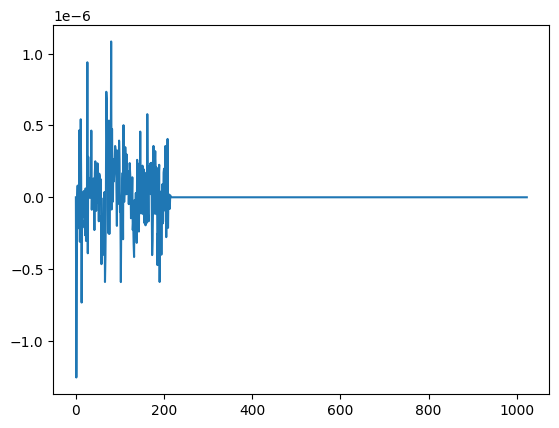

In [84]:
import matplotlib.pyplot as plt
plt.plot(sum_attributions[55])
plt.show()

In [63]:
preds = []
for r in enzyme_iterator():
    seq_ind, mask =  torch.tensor(r['seq_ind']).to(device), torch.BoolTensor(r['mask']).to(device)
    goind_model.go_idx = r['go_ind']
    model_pred = goind_model(seq_ind, mask)
    preds.append(model_pred.detach().cpu().item())

357


In [13]:
# display(enzyme_dataset)
print(enzyme_term_index)

[12611, 6256, 1500, 19157, 2030, 6171, 4752, 5036, 805, 12480, 2661, 19723, 3226, 253, 4827, 17904, 5494, 694, 20343, 1833, 3963, 14894, 11962, 694, 7078, 9930, 25486, 3821, 782, 28, 5155, 20517, 24854, 4008, 6247, -1, 5355, 19888, 26924, 1251, 1251, 826, 2744, 1681, 1681, 1681, 2885, 4284, 9783, 8105, 2030, 1606, 709, 1003, 599, 540, 5994, 2788, 2487, 723, 1638, 2356, 9144, 87, 1252, 15352, 2793, 566, 4740, 501, 7530, 14742, 1543, 1543, 1669, 1895, 25263, 120, 120, 120, 120, 120, 2499, 2880, 1656, 847, 4612, 5183, 798, 1221, 7929, 1379, 255, 8264, 405, 2700, 1103, 478, 1255, 1397, 1439, 1559, 230, 351, 694, 1618, 16654, 1081, 2779, 839, 1025, 4805, 4894, 2063, 397, 7145, 3143, 1678, 2757, -1, 2276, 18670, 24940, 392, 702, 2715, 694, 19723, 2897, 740, 1457, 61, 1731, 12358, 2569, 14233, 12008, 1678, 12107, 6077, 216, 750, 9039, 6254, 525, 42, 5581, 1214, 16654, 1343, 12522, 7079, 7936, 13439, 16461, 518, 439, 1068, 22128, 590, 8259, 1911, 1833, 2726, 336, 5316, 288, 443, 222, -1, 1039,